   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000 

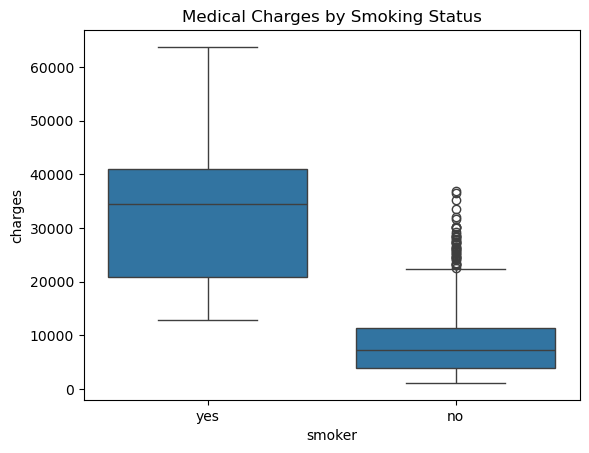

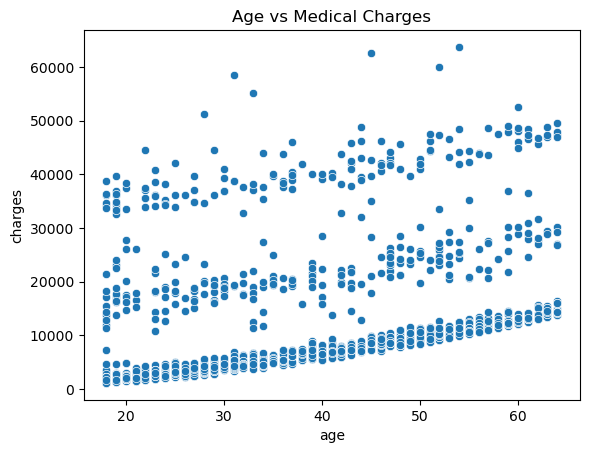


--- REGRESSION RESULTS ---
R2 Score: 0.7835929767120724
MAE: 4181.1944737536505

--- CLASSIFICATION RESULTS ---
Accuracy: 0.9402985074626866
Confusion Matrix:
 [[198   0]
 [ 16  54]]

--- KEY INSIGHTS ---
1. Smoking significantly increases medical costs.
2. Age and BMI are important predictors.
3. Model can identify high-cost patients with reasonable accuracy.


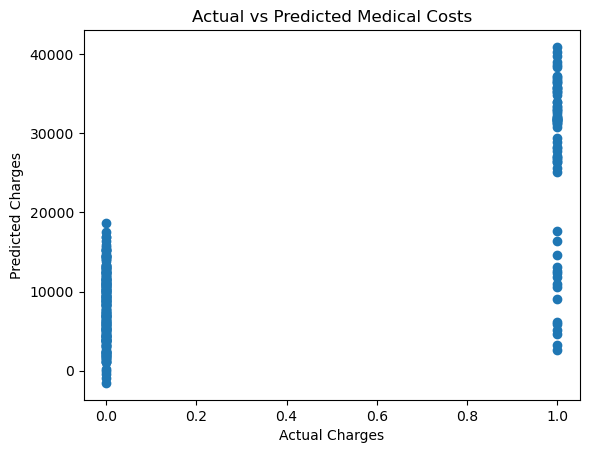

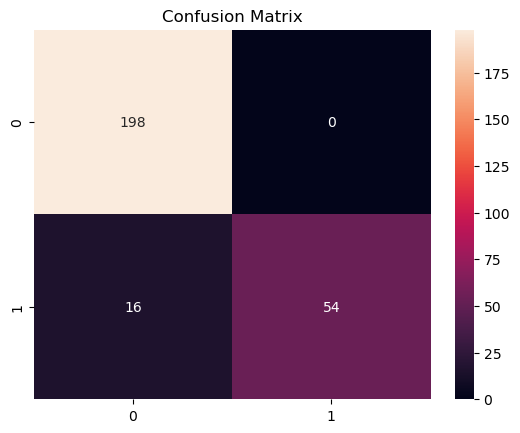

In [1]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score, confusion_matrix

# ================================
# 2. LOAD DATA
# ================================
df = pd.read_csv("insurance.csv")
# посмотреть данные
print(df.head())

# ================================
# 3. DATA EXPLORATION (EDA)
# ================================
print(df.info())
print(df.describe())

# график: влияние курения
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Medical Charges by Smoking Status")
plt.show()

# график: возраст vs расходы
sns.scatterplot(x="age", y="charges", data=df)
plt.title("Age vs Medical Charges")
plt.show()

# ================================
# 4. DATA PREPROCESSING
# ================================
# преобразуем категориальные переменные
df_encoded = pd.get_dummies(df, drop_first=True)

# ================================
# 5. REGRESSION MODEL
# ================================
X_reg = df_encoded.drop("charges", axis=1)
y_reg = df_encoded["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# обучаем модель
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# предсказания
y_pred_reg = reg_model.predict(X_test)

# оценка
print("\n--- REGRESSION RESULTS ---")
print("R2 Score:", r2_score(y_test, y_pred_reg))
print("MAE:", mean_absolute_error(y_test, y_pred_reg))

# ================================
# 6. CLASSIFICATION MODEL
# ================================
# создаём новую целевую переменную
df_encoded["high_cost"] = (df_encoded["charges"] > 15000).astype(int)

X_clf = df_encoded.drop(["charges", "high_cost"], axis=1)
y_clf = df_encoded["high_cost"]

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

# обучаем модель
clf_model = LogisticRegression(max_iter=1000)
clf_model.fit(X_train, y_train)

# предсказания
y_pred_clf = clf_model.predict(X_test)

# оценка
print("\n--- CLASSIFICATION RESULTS ---")
print("Accuracy:", accuracy_score(y_test, y_pred_clf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_clf))

# ================================
# 7. FINAL INSIGHTS
# ================================
print("\n--- KEY INSIGHTS ---")
print("1. Smoking significantly increases medical costs.")
print("2. Age and BMI are important predictors.")
print("3. Model can identify high-cost patients with reasonable accuracy.")
# ================================
# 8. VISUALIZATION
# ================================
import matplotlib.pyplot as plt
import seaborn as sns

# Regression: фактические vs предсказанные
plt.scatter(y_test, y_pred_reg)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Medical Costs")
plt.show()

# Classification: Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_clf), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()